In [1]:
# Project: DS 4002 – Snow Stormers
# Authors: Aleeza Sadiq, Austin Blackburn, Jacob VanBenschoten
# Date: Spring 2026

In [2]:
# Purpose:
# This script evaluates the predictive accuracy of a pretrained
# HuggingFace RoBERTa sentiment model on Letterboxd movie reviews.
# It generates sentiment predictions, engineers text features,
# computes classification metrics, and analyzes model accuracy
# across linguistic characteristics.

# Inputs:
# - letterboxd_top250_reviews_clean.csv

# Outputs:
# - full_feature_engineering_table.csv
# - model_performance.csv
# - confusion_matrix.csv
# - confusion_matrix.png
# - accuracy_by_language.csv
# - accuracy_by_emoji.csv
# - accuracy_by_length.csv
# - accuracy_by_caps_ratio.csv
# - accuracy_by_low_text_content.csv

In [7]:
!pip install emoji
!pip install langdetect

# To Run:
# python 03_model_analysis.py

import pandas as pd
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import re
import emoji
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Load your cleaned dataset CSV
df = pd.read_csv("letterboxd_top250_reviews_clean.csv")

In [9]:
# Remove empty reviews (prevents rare tokenizer crashes)
df = df[df["review_text"].astype(str).str.strip().str.len() > 0].copy()

In [10]:
# --- Step A: Convert star_rating -> true sentiment category (preregistered bins) ---
def stars_to_label(stars: float) -> str:
    #  Converts numeric star ratings (0.5–5.0) into
    #three sentiment categories based on preregistered bins:
    #<2.5 = negative
    #2.5–3.5 = neutral
    #>3.5 = positive
    if stars < 2.5:
        return "negative"
    elif stars <= 3.5:
        return "neutral"
    else:
        return "positive"

df["true_label"] = df["star_rating"].apply(stars_to_label)

In [11]:
# --- Step B: Load HuggingFace sentiment model (LOCAL; no token needed) ---
model_id = "cardiffnlp/twitter-roberta-base-sentiment-latest"
sentiment_pipe = pipeline("sentiment-analysis", model=model_id, tokenizer=model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [12]:
# --- Step C: Run predictions in batches (fast + safe) ---
texts = df["review_text"].astype(str).tolist()

batch_size = 32
pred_labels = []
pred_scores = []

for i in tqdm(range(0, len(texts), batch_size), desc="Running HF sentiment"):
    batch = texts[i:i+batch_size]
    preds = sentiment_pipe(batch, truncation=True, max_length=512) # truncation avoids very long text issues
    pred_labels.extend([p["label"].lower() for p in preds])   # labels: 'positive', 'neutral', 'negative'
    pred_scores.extend([p["score"] for p in preds])

df["pred_label"] = pred_labels
df["pred_score"] = pred_scores

Running HF sentiment: 100%|██████████| 149/149 [01:00<00:00,  2.46it/s]


In [13]:
# --- Step D: Optional neutral confidence threshold (0.4–0.6) ---
# If confidence is near the boundary, force neutral (TA request)
def apply_neutral_threshold(label, score, low=0.4, high=0.6):
    if low <= score <= high:
        return "neutral"
    return label

df["pred_label_thresh"] = [
    apply_neutral_threshold(l, s, 0.4, 0.6) for l, s in zip(df["pred_label"], df["pred_score"])
]

In [14]:
# --- Step E: Evaluate ---
y_true = df["true_label"]
y_pred = df["pred_label_thresh"]

df["correct"] = (df["true_label"] == df["pred_label_thresh"])

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 (macro):", f1_score(y_true, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred, labels=["negative", "neutral", "positive"]))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

print(df["true_label"].value_counts(normalize=True))

df["review_len"] = df["review_text"].str.len()

Accuracy: 0.36635120925341746
F1 (macro): 0.22253661256481108

Confusion Matrix:
 [[  23   17    7]
 [ 102  113   67]
 [1070 1750 1606]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.02      0.49      0.04        47
     neutral       0.06      0.40      0.10       282
    positive       0.96      0.36      0.53      4426

    accuracy                           0.37      4755
   macro avg       0.35      0.42      0.22      4755
weighted avg       0.89      0.37      0.50      4755

true_label
positive    0.930810
neutral     0.059306
negative    0.009884
Name: proportion, dtype: float64


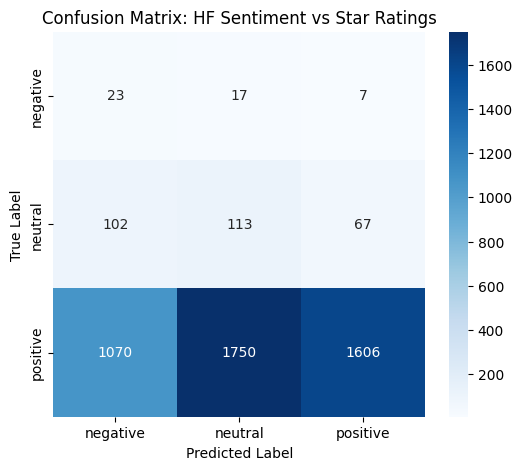

In [15]:
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: HF Sentiment vs Star Ratings")
plt.show()

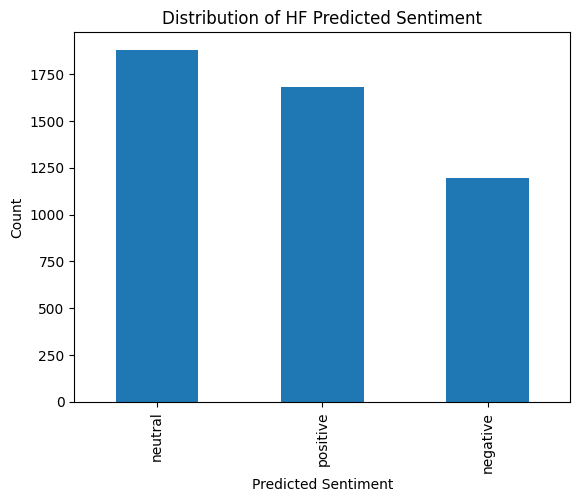

In [16]:
df["pred_label_thresh"].value_counts().plot(kind="bar")
plt.title("Distribution of HF Predicted Sentiment")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Count")
plt.show()

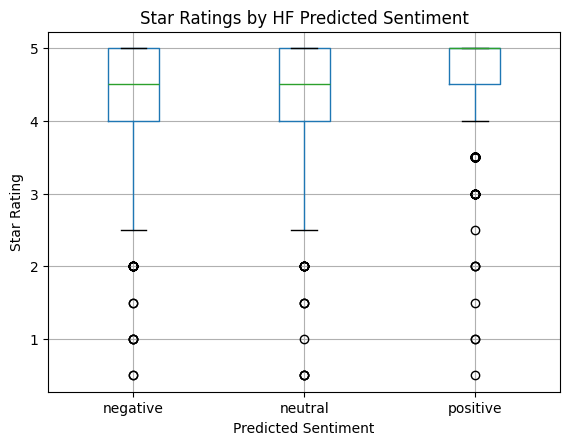

In [17]:
df.boxplot(column="star_rating", by="pred_label_thresh")
plt.title("Star Ratings by HF Predicted Sentiment")
plt.suptitle("")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Star Rating")
plt.show()

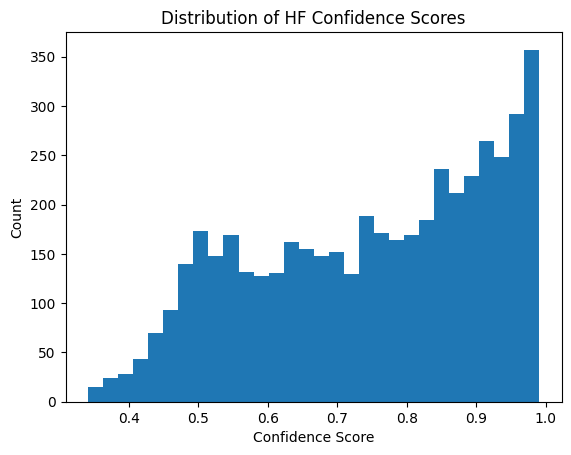

In [18]:
df["pred_score"].plot(kind="hist", bins=30)
plt.title("Distribution of HF Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.show()

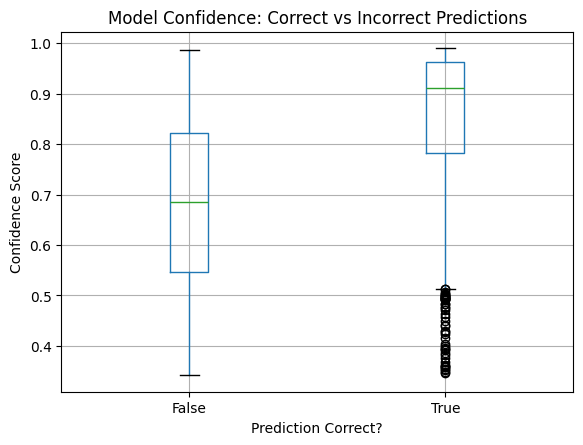

In [19]:
df["correct"] = df["true_label"] == df["pred_label_thresh"]

df.boxplot(column="pred_score", by="correct")
plt.title("Model Confidence: Correct vs Incorrect Predictions")
plt.suptitle("")
plt.xlabel("Prediction Correct?")
plt.ylabel("Confidence Score")
plt.show()

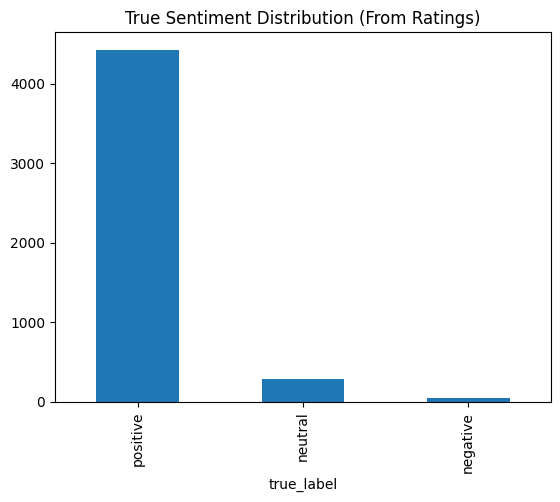

In [20]:
df["true_label"].value_counts().plot(kind="bar")
plt.title("True Sentiment Distribution (From Ratings)")
plt.show()

In [21]:
# --- Feature Engineering ---

# 1) Review character length
df["review_char_len"] = df["review_text"].astype(str).str.len()

In [22]:
# 2) Review word count
df["review_word_count"] = df["review_text"].astype(str).str.split().str.len()

In [23]:
# 3) Emoji count
def count_emojis(text):
    text = str(text)
    return sum(1 for ch in text if ch in emoji.EMOJI_DATA)

df["emoji_count"] = df["review_text"].apply(count_emojis)
df["has_emoji"] = df["emoji_count"] > 0

# 4) Capitalization ratio (uppercase letters / total letters)
def caps_ratio(text):
    text = str(text)
    letters = [c for c in text if c.isalpha()]
    if len(letters) == 0:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

df["caps_ratio"] = df["review_text"].apply(caps_ratio)

# 5) Basic "has URL" flag
url_pattern = re.compile(r"http[s]?://|www\.")
df["has_url"] = df["review_text"].astype(str).apply(lambda x: bool(url_pattern.search(x)))

# 6) Punctuation intensity (simple proxy for tone)
def exclam_count(text):
    return str(text).count("!")

In [24]:
def question_count(text):
    return str(text).count("?")

df["exclam_count"] = df["review_text"].apply(exclam_count)
df["question_count"] = df["review_text"].apply(question_count)

# 7) Language detection (safe)
def detect_language_safe(text):
    try:
        t = str(text).strip()
        if len(t) < 5:   # too short often fails
            return "unknown"
        return detect(t)
    except LangDetectException:
        return "unknown"

df["language"] = df["review_text"].apply(detect_language_safe)

In [25]:
# 8) Simple "is mostly non-text" flag (emoji-only / very low alphabetic content)
def alpha_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0.0
    alpha = sum(1 for c in text if c.isalpha())
    return alpha / len(text)

df["alpha_ratio"] = df["review_text"].apply(alpha_ratio)
df["low_text_content"] = df["alpha_ratio"] < 0.20  # tweakable threshold

print("\n✅ Feature engineering complete.")
print(df[[
    "review_text",
    "review_char_len",
    "review_word_count",
    "emoji_count",
    "caps_ratio",
    "has_url",
    "exclam_count",
    "question_count",
    "language",
    "low_text_content"
]].head(5))


✅ Feature engineering complete.
                                         review_text  review_char_len  \
0  honor in the individual is virtue honor in a s...               63   
1  Firstly, I must apologise for holding off on t...              500   
2  God damn what an impeccable film. Not dated in...              547   
3  Probably the greatest film ever.. a film about...              177   
4  Immediately pulls you in with its captivating ...              614   

   review_word_count  emoji_count  caps_ratio  has_url  exclam_count  \
0                 12            0    0.000000    False             0   
1                 82            0    0.024876    False             0   
2                102            0    0.016432    False             0   
3                 31            0    0.007299    False             0   
4                 97            0    0.009881    False             0   

   question_count language  low_text_content  
0               0       en             False  
1

In [26]:
print("\n=== Feature Summary Statistics ===")
print(df[[
    "review_char_len",
    "review_word_count",
    "emoji_count",
    "caps_ratio",
    "exclam_count",
    "question_count"
]].describe())


=== Feature Summary Statistics ===
       review_char_len  review_word_count  emoji_count   caps_ratio  \
count      4755.000000        4755.000000  4755.000000  4755.000000   
mean        200.907256          31.685594     0.228181     0.053150   
std        1339.724043          27.404682     3.841995     0.130653   
min           4.000000           1.000000     0.000000     0.000000   
25%          59.000000          11.000000     0.000000     0.000000   
50%         114.000000          21.000000     0.000000     0.025974   
75%         272.000000          47.000000     0.000000     0.048820   
max       91885.000000         115.000000   180.000000     1.000000   

       exclam_count  question_count  
count   4755.000000     4755.000000  
mean       0.246688        0.183176  
std        1.517507        0.873276  
min        0.000000        0.000000  
25%        0.000000        0.000000  
50%        0.000000        0.000000  
75%        0.000000        0.000000  
max       48.000000 

In [27]:
print(df["language"].value_counts())
print(df["has_emoji"].mean())
print(df["low_text_content"].mean())

df.to_csv("full_feature_engineering_table.csv", index=False)
print("Saved full feature table to CSV.")

metrics_df = pd.DataFrame({
    "Accuracy": [accuracy_score(y_true, y_pred)],
    "Macro_F1": [f1_score(y_true, y_pred, average="macro")]
})

language
en         4419
de           43
ar           34
af           30
pt           23
cy           21
es           20
unknown      15
fr           14
no           13
tl           13
id           12
ro           11
so           11
ca           10
et           10
nl           10
it           10
sw            5
sv            5
tr            4
fi            4
vi            4
da            3
pl            2
sk            2
hu            2
hr            1
sq            1
sl            1
el            1
cs            1
Name: count, dtype: int64
0.03827549947423765
0.0014721345951629863
Saved full feature table to CSV.


In [28]:
metrics_df.to_csv("model_performance.csv", index=False)
print("Saved: model_performance.csv")

Saved: model_performance.csv


In [29]:
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv("confusion_matrix.csv")
print("Saved: confusion_matrix.csv")

Saved: confusion_matrix.csv


In [30]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.close()
print("Saved: confusion_matrix.png")

Saved: confusion_matrix.png


In [31]:
language_acc = df.groupby("language").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean")
).sort_values("n", ascending=False)

language_acc.to_csv("accuracy_by_language.csv")
print("Saved: accuracy_by_language.csv")

Saved: accuracy_by_language.csv


In [32]:
emoji_acc = df.groupby("has_emoji").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean")
)

emoji_acc.to_csv("accuracy_by_emoji.csv")
print("Saved: accuracy_by_emoji.csv")

Saved: accuracy_by_emoji.csv


In [33]:
df["len_bin"] = pd.qcut(df["review_char_len"], 4, duplicates="drop")

length_acc = df.groupby("len_bin").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean")
)

length_acc.to_csv("accuracy_by_length.csv")
print("Saved: accuracy_by_length.csv")

Saved: accuracy_by_length.csv


/tmp/ipython-input-3203838731.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_acc = df.groupby("len_bin").agg(


In [34]:
df["caps_bin"] = pd.qcut(df["caps_ratio"], 4, duplicates="drop")

caps_acc = df.groupby("caps_bin").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean")
)

caps_acc.to_csv("accuracy_by_caps_ratio.csv")
print("Saved: accuracy_by_caps_ratio.csv")

Saved: accuracy_by_caps_ratio.csv


/tmp/ipython-input-1262510416.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  caps_acc = df.groupby("caps_bin").agg(


In [35]:
low_text_acc = df.groupby("low_text_content").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean")
)

low_text_acc.to_csv("accuracy_by_low_text_content.csv")
print("Saved: accuracy_by_low_text_content.csv")

Saved: accuracy_by_low_text_content.csv


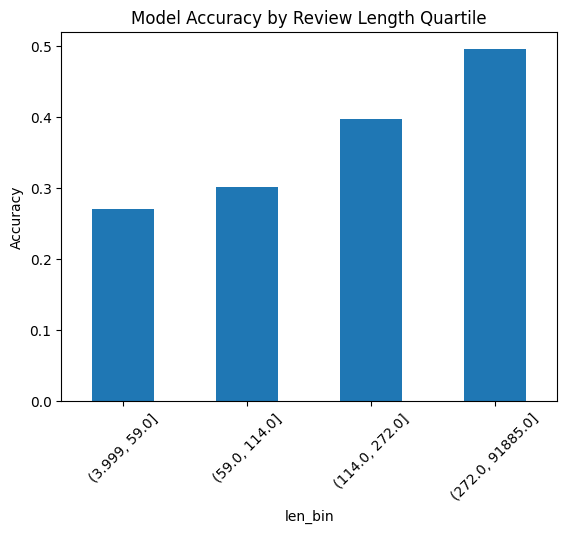

In [46]:
#Accuracy by Review Length (Bar Chart)
length_acc["accuracy"].plot(kind="bar")
plt.title("Model Accuracy by Review Length Quartile")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()


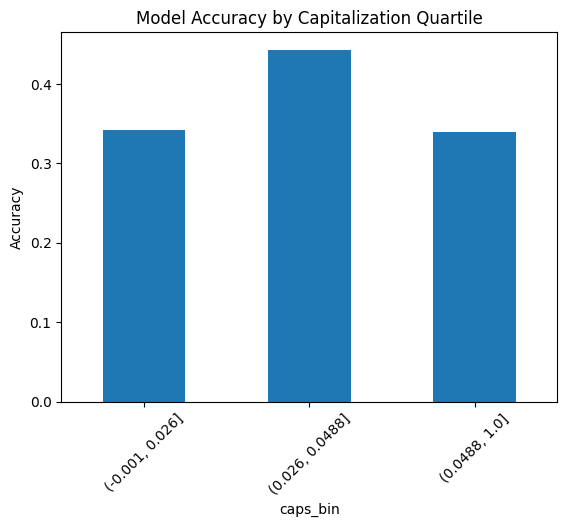

In [47]:
#Accuracy by Capitalization Ratio
caps_acc["accuracy"].plot(kind="bar")
plt.title("Model Accuracy by Capitalization Quartile")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

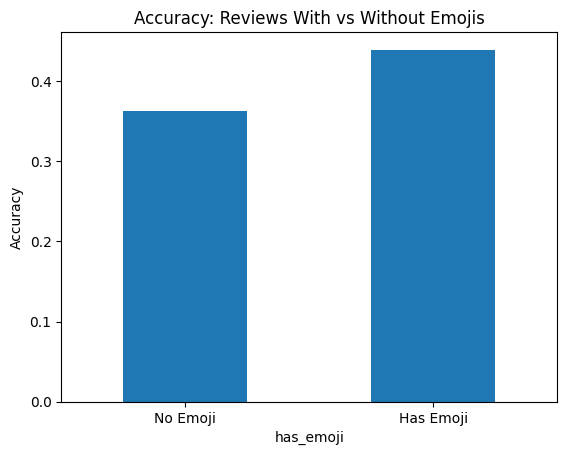

In [48]:
#Accuracy by Emoji Usage
emoji_acc["accuracy"].plot(kind="bar")
plt.title("Accuracy: Reviews With vs Without Emojis")
plt.xticks([0,1], ["No Emoji", "Has Emoji"], rotation=0)
plt.ylabel("Accuracy")
plt.show()

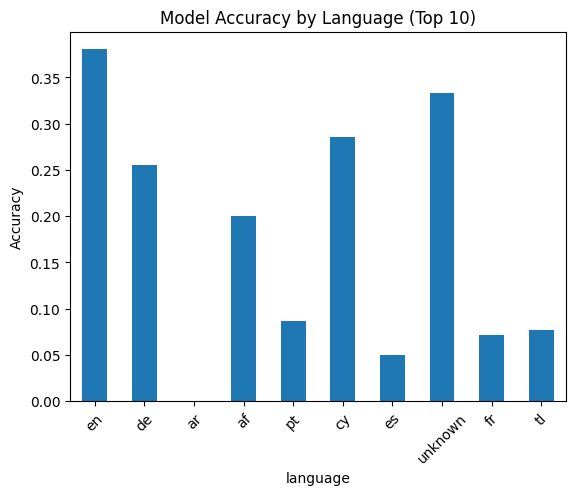

In [49]:
#Accuracy by Language (Top 10 Only)
top_lang = language_acc.head(10)
top_lang["accuracy"].plot(kind="bar")
plt.title("Model Accuracy by Language (Top 10)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

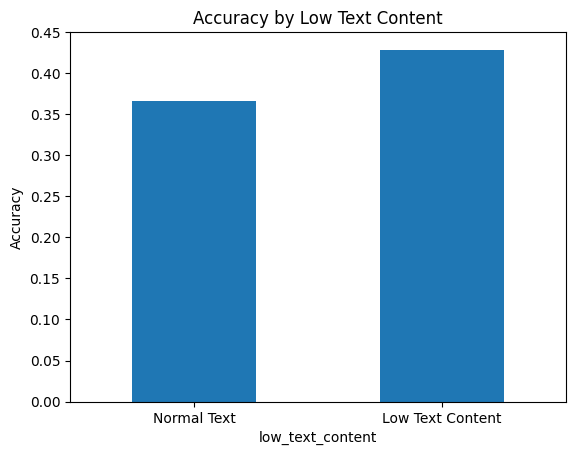

In [50]:
#Low Text Content vs Accuracy
low_text_acc["accuracy"].plot(kind="bar")
plt.title("Accuracy by Low Text Content")
plt.xticks([0,1], ["Normal Text", "Low Text Content"], rotation=0)
plt.ylabel("Accuracy")
plt.show()


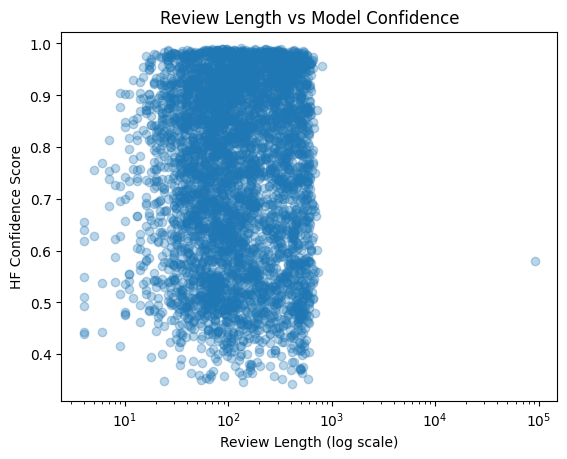

In [51]:
#Review Length vs Model Confidence
plt.scatter(df["review_char_len"], df["pred_score"], alpha=0.3)
plt.xscale("log")
plt.title("Review Length vs Model Confidence")
plt.xlabel("Review Length (log scale)")
plt.ylabel("HF Confidence Score")
plt.show()